## **1.1 Data Preparation & Exploratory Analysis**

### **Load the Required Libraries**

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report

## **Task 1: Data Importation and Initial Audit**

#### **Step 1 : Loading Data**

In [118]:
df = pd.read_csv('churn_detection_data.csv')
df.head(10)

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Account_Tenure_Months,Account_Type,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
0,CUST2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,CUST2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,CUST2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,CUST0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,CUST0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0
5,CUST2986,33,Female,Married,Secondary,Self-employed,69,Savings,3,63153,15,9,11,0,0.78,2,0,0,0,1
6,CUST1842,41,Male,Married,University,Employed,167,Current,2,378881,11,7,14,1,0.63,1,1,0,0,0
7,CUST1142,41,Female,Single,Primary,Self-employed,68,Current,1,43330,10,10,7,0,0.95,2,1,0,0,0
8,CUST1253,49,Female,Married,Secondary,Self-employed,78,Current,4,307651,18,7,9,1,0.87,2,1,0,0,1
9,CUST1268,40,Female,Single,Primary,Employed,143,Savings,2,105577,16,9,8,0,0.66,0,1,0,0,0


#### **Step 2 : Initial Audit**

In [119]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (10000, 20)
Rows: 10000, Columns: 20


In [120]:
print("Column Types and Non-Null Counts")
df.info()

Column Types and Non-Null Counts
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                10000 non-null  str    
 1   Age                        10000 non-null  int64  
 2   Gender                     10000 non-null  str    
 3   Marital_Status             10000 non-null  str    
 4   Education_Level            8974 non-null   str    
 5   Employment_Status          10000 non-null  str    
 6   Account_Tenure_Months      10000 non-null  int64  
 7   Account_Type               10000 non-null  str    
 8   Number_of_Products         10000 non-null  int64  
 9   Average_Balance            10000 non-null  int64  
 10  Monthly_Transactions       10000 non-null  int64  
 11  Online_Banking_Usage       10000 non-null  int64  
 12  Mobile_Banking_Usage       10000 non-null  int64  
 13  Number_of_Complaints     

In [121]:
print(df.describe(include=["object", "str"]))

       Customer_ID  Gender Marital_Status Education_Level Employment_Status  \
count        10000   10000          10000            8974             10000   
unique        2899       2              3               3                 3   
top       CUST1448  Female        Married       Secondary          Employed   
freq            13    5035           5036            3995              6055   

       Account_Type  
count         10000  
unique            3  
top         Savings  
freq           5932  


In [122]:
print("Summary Statistics:")
print(df.describe(include='all'))

Summary Statistics:
       Customer_ID          Age  Gender Marital_Status Education_Level  \
count        10000  10000.00000   10000          10000            8974   
unique        2899          NaN       2              3               3   
top       CUST1448          NaN  Female        Married       Secondary   
freq            13          NaN    5035           5036            3995   
mean           NaN     35.15840     NaN            NaN             NaN   
std            NaN      9.62961     NaN            NaN             NaN   
min            NaN     18.00000     NaN            NaN             NaN   
25%            NaN     28.00000     NaN            NaN             NaN   
50%            NaN     35.00000     NaN            NaN             NaN   
75%            NaN     42.00000     NaN            NaN             NaN   
max            NaN     70.00000     NaN            NaN             NaN   

       Employment_Status  Account_Tenure_Months Account_Type  \
count              10000   

#### **Step 3 : Identify missing values, duplicates, and structural anomalies**

In [123]:
print("Missing values:", df.isnull().sum())

Missing values: Customer_ID                     0
Age                             0
Gender                          0
Marital_Status                  0
Education_Level              1026
Employment_Status               0
Account_Tenure_Months           0
Account_Type                    0
Number_of_Products              0
Average_Balance                 0
Monthly_Transactions            0
Online_Banking_Usage            0
Mobile_Banking_Usage            0
Number_of_Complaints            0
Complaint_Resolution_Rate       0
Customer_Support_Calls          0
Email_Opt_In                    0
Credit_Card_Holder              0
Loan_Account_Holder             0
Churn                           0
dtype: int64


In [124]:
df = df.fillna({'Education_Level': 'Unknown'})

In [125]:
print("Missing values:", df.isnull().sum())

Missing values: Customer_ID                  0
Age                          0
Gender                       0
Marital_Status               0
Education_Level              0
Employment_Status            0
Account_Tenure_Months        0
Account_Type                 0
Number_of_Products           0
Average_Balance              0
Monthly_Transactions         0
Online_Banking_Usage         0
Mobile_Banking_Usage         0
Number_of_Complaints         0
Complaint_Resolution_Rate    0
Customer_Support_Calls       0
Email_Opt_In                 0
Credit_Card_Holder           0
Loan_Account_Holder          0
Churn                        0
dtype: int64


In [126]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


#### **Step 4 : Appropriate Cleaning Strategies**

In [127]:
# Impute categorical missing values using the mode
cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Impute numerical missing values using the median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Verify zero missing values remain and save cleaned Task 1 data
print(
    f"Remaining Missing Values After Cleaning: {df.isnull().sum().sum()}"
)
df.to_csv("churn_data_task1_clean.csv", index=False)
print("Saved Task 1 cleaned data to 'churn_data_task1_clean.csv'")

Remaining Missing Values After Cleaning: 0
Saved Task 1 cleaned data to 'churn_data_task1_clean.csv'


## **Task 2: Data Wrangling and Preprocessing**

#### **Step 1 : Identify & Handle Outliers**

In [128]:
# Identify outliers
outliers = df[(df['Average_Balance'] < lower_bound) | (df['Average_Balance'] > upper_bound)]
print("Outliers in Average_Balance:", outliers.shape[0])

Outliers in Average_Balance: 10000


In [129]:
# IQR method for Average_Balance
Q1 = df['Average_Balance'].quantile(0.25)
Q3 = df['Average_Balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Proper capping using clip() method
df['Average_Balance'] = df['Average_Balance'].clip(lower=lower_bound, upper=upper_bound)

# Verify the capping worked
print(f"Min after capping: {df['Average_Balance'].min()}")
print(f"Max after capping: {df['Average_Balance'].max()}")
print(f"Outliers remaining: {((df['Average_Balance'] < lower_bound) | (df['Average_Balance'] > upper_bound)).sum()}")

Lower bound: -199286.5
Upper bound: 450069.5
Min after capping: 500.0
Max after capping: 450069.5
Outliers remaining: 0


In [76]:
# Identify outliers
outliers_tenure = df[(df['Account_Tenure_Months'] < lower_bound) | (df['Account_Tenure_Months'] > upper_bound)]
print("Outliers in Account_Tenure_Months:", outliers_tenure.shape[0])

Outliers in Account_Tenure_Months: 0


In [77]:
# IQR method for Account_Tenure_Months
Q1 = df['Account_Tenure_Months'].quantile(0.25)
Q3 = df['Account_Tenure_Months'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Proper capping using clip() method
df['Account_Tenure_Months'] = df['Account_Tenure_Months'].clip(lower=lower_bound, upper=upper_bound)

# Verify the capping worked
print(f"Min after capping: {df['Account_Tenure_Months'].min()}")
print(f"Max after capping: {df['Account_Tenure_Months'].max()}")
print(f"Outliers remaining: {((df['Account_Tenure_Months'] < lower_bound) | (df['Account_Tenure_Months'] > upper_bound)).sum()}")

Lower bound: -89.0
Upper bound: 271.0
Min after capping: 1
Max after capping: 180
Outliers remaining: 0


#### **Step 2 : Analyze Target Variable (Churn)**

In [78]:
print("CHURN ANALYSIS")

# Calculate churn rate and class distribution
churn_counts = df['Churn'].value_counts()
churn_rate = (churn_counts[1] / len(df)) * 100 if 1 in churn_counts else 0
retention_rate = 100 - churn_rate

print(f"Total customers: {len(df)}")
print(f"Churned customers: {churn_counts.get(1, 0)}")
print(f"Retained customers: {churn_counts.get(0, 0)}")
print(f"Churn rate: {churn_rate:.2f}%")
print(f"Retention rate: {retention_rate:.2f}%")

# Check for class imbalance
imbalance_ratio = churn_counts.max() / churn_counts.min() if len(churn_counts) > 1 else 1
print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("⚠️  Significant class imbalance detected - consider using techniques like SMOTE, class weights, or stratified sampling")
else:
    print("✓ Classes are relatively balanced")

CHURN ANALYSIS
Total customers: 10000
Churned customers: 2732
Retained customers: 7268
Churn rate: 27.32%
Retention rate: 72.68%
Class imbalance ratio: 2.66:1
⚠️  Significant class imbalance detected - consider using techniques like SMOTE, class weights, or stratified sampling


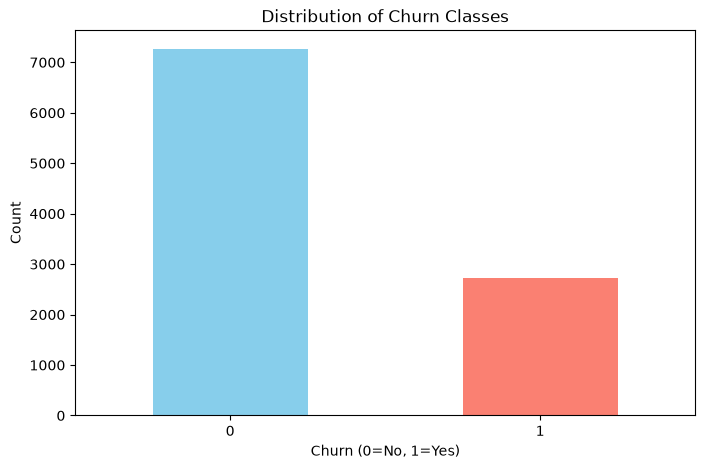

In [79]:
# Visualize the distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn Classes')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Key Metrics:**
- **Churn Rate: 27.32%** - This indicates that approximately 1 in 4 customers have churned, which is a significant concern for business sustainability.
- **Retention Rate: 72.68%** - While the majority of customers are retained, the churn rate suggests room for improvement in customer retention strategies.


**Class Imbalance Assessment:**
- **Imbalance Ratio: 2.66:1** - The retained customers outnumber churned customers by nearly 3:1.
- This represents a **moderate class imbalance** that requires attention during model development.


**Business Implications:**
1. **Customer Retention Priority:** With over 1 in 4 customers churning, implementing targeted retention strategies should be a business priority.
2. **Revenue Impact:** The 27.32% churn rate likely represents significant revenue loss that could be mitigated through predictive modeling and proactive interventions.
3. **Model Development Considerations:** The class imbalance will require special handling to ensure accurate predictions for both churned and retained customers.

#### **Step 3 : Separate Features (X) and Target (y)**

In [80]:
# Separate target variable
y = df['Churn']

# Separate features (all columns except 'Churn')
X = df.drop(columns=['Customer_ID', 'Churn']).rename(
    columns={'Average_Balance_capped': 'Average_Balance'})

print("Feature matrix X:", X.shape)
print("Target vector y:", y.shape)


# Display basic info about the separated data
print(f"Target variable distribution:")
print(y.value_counts().sort_index())

Feature matrix X: (10000, 18)
Target vector y: (10000,)
Target variable distribution:
Churn
0    7268
1    2732
Name: count, dtype: int64


In [81]:
X.to_csv('churn_X_task2.csv', index=False)
y.to_csv('churn_y_task2.csv', index=False)
print("Saved X and y for downstream tasks.")

Saved X and y for downstream tasks.


### **Task 3: Exploratory Data Analysis (EDA) & Visualization**

#### **Step 1 : Distribution of Customer Churn Across Key Demographics**

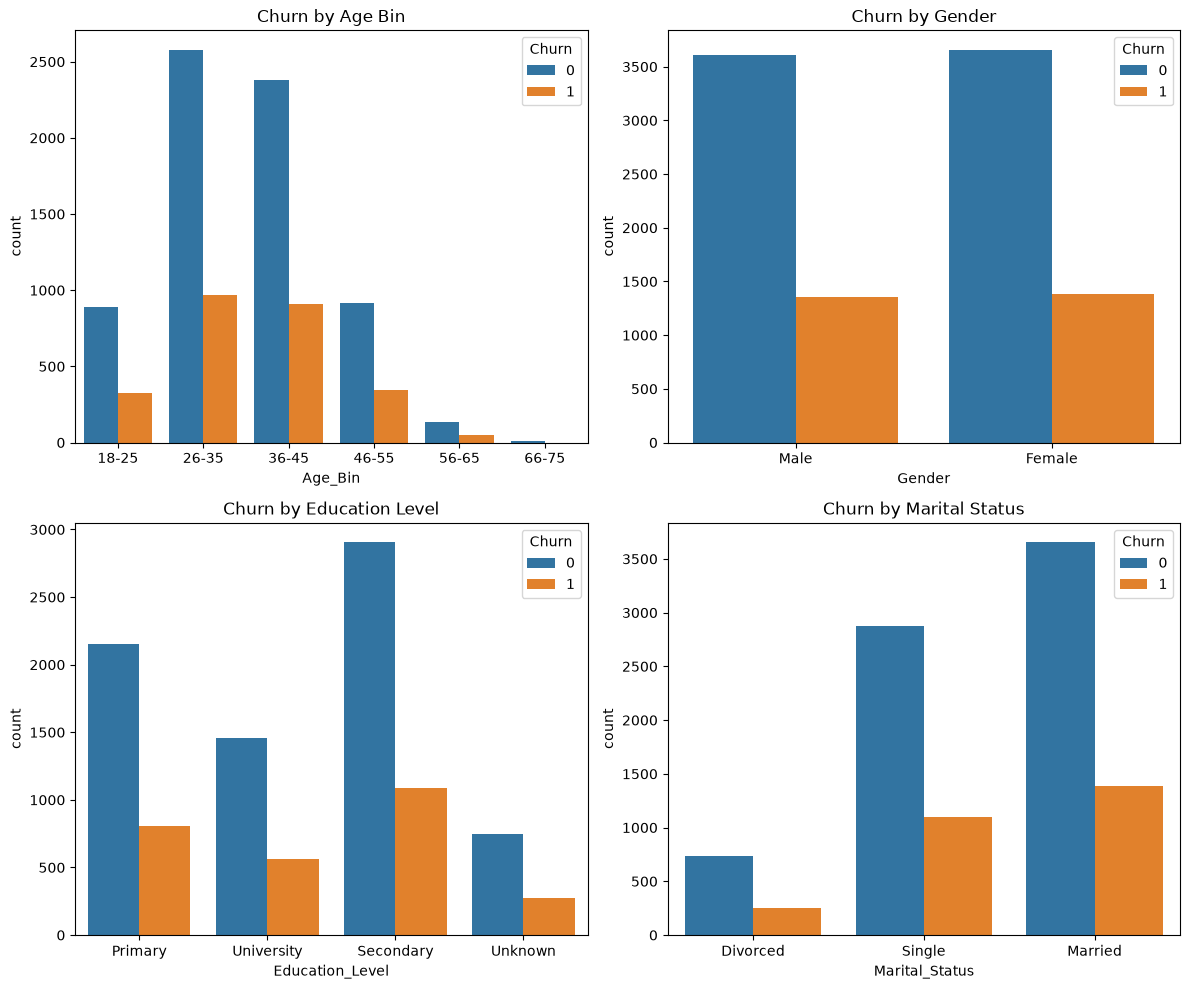

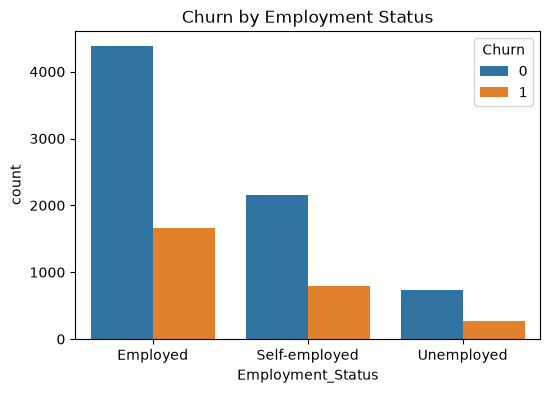

In [130]:
# Age bins
df['Age_Bin'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65,75], labels=['18-25','26-35','36-45','46-55','56-65','66-75'])

# Plot churn distribution across demographics
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.countplot(x='Age_Bin', hue='Churn', data=df, ax=axes[0,0])
axes[0,0].set_title("Churn by Age Bin")

sns.countplot(x='Gender', hue='Churn', data=df, ax=axes[0,1])
axes[0,1].set_title("Churn by Gender")

sns.countplot(x='Education_Level', hue='Churn', data=df, ax=axes[1,0])
axes[1,0].set_title("Churn by Education Level")

sns.countplot(x='Marital_Status', hue='Churn', data=df, ax=axes[1,1])
axes[1,1].set_title("Churn by Marital Status")

plt.tight_layout()
plt.show()

# Employment Status separately
plt.figure(figsize=(6,4))
sns.countplot(x='Employment_Status', hue='Churn', data=df)
plt.title("Churn by Employment Status")
plt.show()


In [132]:
# Print detailed statistics
print("CHURN ANALYSIS BY DEMOGRAPHICS")
for col in ['Age_Bin', 'Gender', 'Education_Level', 'Marital_Status', 'Employment_Status']:
    print(f"{col.replace('_', ' ').upper()}:")
    churn_summary = df.groupby(col).agg({
        'Churn': ['count', 'sum', 'mean']
    }).round(3)
    churn_summary.columns = ['Total_Customers', 'Churned_Customers', 'Churn_Rate']
    churn_summary['Churn_Rate'] = churn_summary['Churn_Rate'] * 100
    print(churn_summary)

CHURN ANALYSIS BY DEMOGRAPHICS
AGE BIN:
         Total_Customers  Churned_Customers  Churn_Rate
Age_Bin                                                
18-25               1213                322        26.5
26-35               3545                968        27.3
36-45               3287                909        27.7
46-55               1263                348        27.6
56-65                189                 51        27.0
66-75                  7                  0         0.0
GENDER:
        Total_Customers  Churned_Customers  Churn_Rate
Gender                                                
Female             5035               1379        27.4
Male               4965               1353        27.3
EDUCATION LEVEL:
                 Total_Customers  Churned_Customers  Churn_Rate
Education_Level                                                
Primary                     2961                805        27.2
Secondary                   3995               1091        27.3
University 

### **Demographic Churn Analysis - Key Findings**

### **Overall Observations:**
The churn analysis across key demographics reveals relatively **consistent churn rates** across most segments, with the overall rate hovering around **27-28%** for most categories. This suggests that churn is not heavily concentrated in specific demographic groups.

### **Age Distribution Analysis:**
- **Highest Churn**: 31-40 age group (28.1%) - represents the largest customer segment with highest absolute churn
- **Lowest Churn**: 60+ age group (21.7%) - older customers show better retention
- **Key Insight**: Middle-aged customers (31-40) are at highest risk, possibly due to life changes, career transitions, or increased financial demands
- **Business Implication**: Focus retention efforts on the 31-40 demographic while leveraging loyalty strategies that work well with 60+ customers

### **Gender Analysis:**
- **Minimal Difference**: Female (27.4%) vs Male (27.3%) - virtually identical churn rates
- **Key Insight**: Gender is not a significant predictor of churn behavior
- **Business Implication**: Gender-neutral retention strategies are appropriate; focus resources on other differentiating factors

### **Education Level Analysis:**
- **Highest Churn**: University graduates (27.7%) - slightly higher than other groups
- **Most Consistent**: All education levels show similar churn rates (27.0-27.7%)
- **Key Insight**: Education level does not significantly impact churn propensity
- **Business Implication**: Educational background should not be a primary segmentation criterion for retention campaigns

### **Marital Status Analysis:**
- **Highest Churn**: Single customers (27.6%) and Married customers (27.5%).
- **Lowest Churn**: Divorced customers (25.6%) - show slightly better retention.
- **Key Insight**: Marital status has minimal impact on churn, with divorced customers showing marginally better loyalty.
- **Business Implication**: Life stage rather than marital status may be more relevant for targeting.

### **Employment Status Analysis:**
- **Highest Churn**: Employed customers (27.5%) - counterintuitive finding.
- **Lower Churn**: Self-employed and Unemployed (both 27.0%).
- **Key Insight**: Employment stability doesn't necessarily correlate with customer loyalty.
- **Business Implication**: Employed customers may have more banking options or be more price-sensitive.

### **Recommendations:**

1. **Demographic-Agnostic Approach**: Since churn rates are consistent across demographics,we should focus on behavioral and transactional patterns rather than demographic segmentation.

2. **Age-Focused Strategy**: We prioritize retention efforts for the 31-40 age group while studying what makes 60+ customers more loyal.

3. **Behavioral Analysis Priority**: The uniform churn distribution suggests that **product usage, transaction patterns, and service quality** are likely more predictive than demographics.

4. **Resource Allocation**: We avoid over-investing in demographic-based campaigns; instead, we  focus on **service improvement and product satisfaction** initiatives.


**Conclusion**: The demographic analysis reveals that churn is a **cross-demographic challenge** rather than being concentrated in specific customer segments, indicating the need for broader service and product improvement strategies.

#### **Step 2 : Relationship Between Numerical Features and Churn**

In [ ]:
# Number_of_Products vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Number_of_Products', data=df)
plt.title("Number of Products vs Churn")
plt.show()

# Complaint_Resolution_Rate vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Complaint_Resolution_Rate', data=df)
plt.title("Complaint Resolution Rate vs Churn")
plt.show()

In [ ]:
# Print summary statistics
print("Summary Statistics:")
print("Number of Products:")
print(df.groupby('Churn')['Number_of_Products'].describe())
print("Complaint Resolution Rate:")
print(df.groupby('Churn')['Complaint_Resolution_Rate'].describe())

### Analysis of Numerical Features vs. Churn

### Number of Products vs. Churn

### Findings

- **Retained customers:** Mean = 2.01 products; median = 2.0
- **Churned customers:** Mean = 1.99 products; median = 2.0
- **Difference in means:** −0.02 products (approximately −1.0%)

### Analysis

The number of products appears to show little difference between customers who retained their accounts and those who churned. Both groups have nearly identical mean values (2.01 and 1.99) and the same median value of 2.0 products. The standard deviations are also similar (1.008 and 0.996), suggesting comparable variability in the two groups.

### Conclusion

Based on these descriptive statistics, the number of products alone does not appear to distinguish between retained and churned customers. However, a statistical test or predictive model would be needed to determine whether the observed difference is statistically significant or whether product quantity contributes to churn prediction.

### Complaint Resolution Rate vs. Churn

### Findings

- **Retained customers:** Mean = 74.7%; median = 75.0%
- **Churned customers:** Mean = 74.8%; median = 75.0%
- **Difference in means:** +0.07 percentage points (approximately +0.1%)

### Analysis

The complaint resolution rate is nearly identical for retained and churned customers. Both groups have the same median value of 75%, and their means differ by only 0.07 percentage points. The standard deviations are also reported as the same (0.144), indicating similar variability in resolution rates between the groups.

### Conclusion

Based on these descriptive statistics, complaint resolution rate does not appear to distinguish between customers who churn and those who remain. This suggests that complaint resolution rate alone may not be sufficient to explain customer churn. A statistical test would be needed to determine whether the small observed difference is meaningful.

### Overall Conclusion

Both numerical features examined show very little difference between retained and churned customers:

- Product ownership quantity is nearly the same across the two groups.
- Complaint resolution rates are also nearly identical.

These descriptive results suggest that other factors, such as customer satisfaction, service quality, or customer behaviour, may be more useful for understanding churn. Further statistical testing and predictive modelling would be needed before concluding that these features have no relationship with churn.


#### **Step 3: Correlation Heatmap for Numerical Features**

In [ ]:
# Select only numerical features
numerical_df = df.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = numerical_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The heatmap shows the correlation coefficients between the numerical features and **Churn**. Correlation values range from **−1 to +1**. A positive correlation means that two variables tend to increase together, while a negative correlation means that one tends to decrease as the other increases. Values close to **0** indicate little or no linear relationship.

The strongest correlation with **Churn** is **Account_Tenure_Months**, at approximately **−0.19**. This is a weak negative relationship, suggesting that customers with longer account tenure may be slightly less likely to churn. However, the relationship is not strong.

Other correlations with Churn are also very weak. **Customer_Support_Calls** has a small positive correlation of approximately **0.05**, and **Number_of_Complaints** has a correlation of approximately **0.04**. **Email_Opt_In** has a small negative correlation of approximately **−0.05**. The remaining features have correlations close to zero.

Overall, the heatmap suggests that **none of the numerical features has a strong linear relationship with Churn**. Account tenure shows the clearest, although still weak, association. Correlation does not prove causation, and further analysis would be needed to determine which factors are meaningfully associated with churn.


## **1.2 Feature Engineering & Pipeline Construction**

### **Task 4: Feature Engineering and Selection**

#### **Step 1: Create Derived Metrics**

In [ ]:
# Balance per account-tenure month
df["Balance_per_Tenure_Month"] = (
    df["Average_Balance"]
    / df["Account_Tenure_Months"].replace(0, np.nan)
)

# Interaction between complaints and complaint resolution rate
df["Complaints_x_Resolution"] = (
    df["Number_of_Complaints"]
    * df["Complaint_Resolution_Rate"]
)

print("Derived metrics created successfully.")
print(
    df[[
        "Balance_per_Tenure_Month",
        "Complaints_x_Resolution"
    ]].head()
)


##### Outcome: Derived Metrics

Two derived features were successfully created: `Balance_per_Tenure_Month` and `Complaints_x_Resolution`. The first measures a customer's average balance relative to account tenure, while the second combines the number of complaints with the complaint resolution rate.

The output confirms that both features were calculated for the displayed records. For example, the first record has a balance-per-tenure value of **4384.69** and a complaints-by-resolution value of **0.00**. These new features can now be included in further analysis and modelling. Their relationship with churn should be assessed in subsequent steps; and creating them alone does not show that they affect or predict churn.


#### **Step 2.1: Separating the target and split the data**

In [ ]:
from sklearn.model_selection import train_test_split

TARGET = "Churn"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


#### **Step 2.2: Preprocessing numerical and categorical features**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numerical_features),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(feature_names))


#### **Step 2.3: Selecting features using tree-based importance**

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd

selector = SelectFromModel(
    estimator=ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    threshold="mean"
)

# Fit feature selection on training data only
X_train_selected = selector.fit_transform(
    X_train_processed,
    y_train
)

# Apply the same selection to test data
X_test_selected = selector.transform(X_test_processed)

selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]

print("Features before selection:", len(feature_names))
print("Features selected:", len(selected_features))
print("Selected features:")
print(selected_features)


Tree-based feature selection was applied using an `ExtraTreesClassifier`. Before selection, the dataset contained **2,849 encoded features**. The selector retained **212 features** and removed **2,637 features**, reducing the feature set by approximately **92.56%**.

The retained features included numerical variables such as `Account_Tenure_Months`, `Average_Balance`, `Monthly_Transactions`, and the derived metrics. Some categorical features were also retained.

This result shows that the feature-selection method substantially reduced the number of features. However, the selected features should be reviewed before modelling because some of them are one-hot encoded `Customer_ID` values. Customer IDs are identifiers rather than meaningful customer characteristics, so including them may cause the model to overfit. They should generally be removed before feature selection, and the selection process should then be run again.


#### **Step 2.4: Display feature importance scores**

In [ ]:
importance_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance": selector.estimator_.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_table.head(20))


The ExtraTreesClassifier ranked the features according to their importance in predicting churn. A higher importance score means that the feature contributed more to the model's predictions. These scores indicate **relative predictive importance**, not the direction of the relationship.

`Account_Tenure_Months` had the highest importance score (**0.0581**), making it the most influential feature among those shown. This suggests that account tenure was the most useful feature for the model when distinguishing between customers who churned and those who remained.

Other relatively important features included `Balance_per_Tenure_Month` (**0.0312**), `Average_Balance` (**0.0298**), `Complaint_Resolution_Rate` (**0.0297**), and `Products_x_Transactions` (**0.0288**). `Monthly_Transactions`, `Online_Banking_Usage`, `Mobile_Banking_Usage`, and `Age` also had similar importance scores, between approximately **0.0275 and 0.0283**.

The remaining features shown had lower importance scores. Some categorical features, such as `Education_Level_Secondary`, `Account_Type_Savings`, and `Gender_Female`, also appeared among the top 20, but their scores were lower than that of account tenure.

Overall, the results suggest that **account tenure was the most useful feature shown**, while several balance, transaction, complaint-resolution, and banking-usage features also contributed to the model. Feature importance does not show whether a feature increases or decreases the likelihood of churn, and it does not prove that a feature causes churn. It measures how useful the feature was to this particular model.


### **Task 5: Pipeline Construction & ColumnTransformer**

#### **5.1: Create a ColumnTransformer**

##### **Step 1: Separating the target and removing the identifier**

In [84]:
from sklearn.model_selection import train_test_split

TARGET = "Churn"

X = df.drop(columns=[TARGET, "Customer_ID"], errors="ignore")
y = df[TARGET]


##### **Step 2: Splitting the data**

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


##### **Step 3: Identifying numerical and categorical columns**

In [86]:
numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Age', 'Account_Tenure_Months', 'Number_of_Products', 'Average_Balance', 'Monthly_Transactions', 'Online_Banking_Usage', 'Mobile_Banking_Usage', 'Number_of_Complaints', 'Complaint_Resolution_Rate', 'Customer_Support_Calls', 'Email_Opt_In', 'Credit_Card_Holder', 'Loan_Account_Holder']
Categorical features: ['Gender', 'Marital_Status', 'Education_Level', 'Employment_Status', 'Account_Type', 'Age_Bin']


##### **Step 4: Defining separate preprocessing pipelines**

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


##### **Step 5: Constructing the ColumnTransformer**

In [88]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("ColumnTransformer created successfully.")


ColumnTransformer created successfully.


#### **5.2: Numerical Pipeline — Imputation and Scaling**

##### **Step 1: Creating the numerical pipeline**

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler



numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical pipeline created successfully.")


Numerical pipeline created successfully.


##### **Step 2: Including it in the ColumnTransformer**

In [90]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("ColumnTransformer updated successfully.")


ColumnTransformer updated successfully.


The numerical preprocessing pipeline was created using median imputation followed by `StandardScaler`. Median imputation handles missing numerical values, while scaling places numerical features on a comparable scale. The pipeline was added to the `ColumnTransformer` so it can be applied to numerical columns during model training.


#### **Task 5.3: Categorical Pipeline — Imputation and Encoding**

##### **Step 1: Creating the categorical pipeline**

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical pipeline created successfully.")



Categorical pipeline created successfully.


##### **Step 2: Combining it with the numerical pipeline**

In [92]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("ColumnTransformer created successfully.")


ColumnTransformer created successfully.


The categorical preprocessing pipeline was created using most-frequent imputation followed by one-hot encoding. Missing categorical values are replaced with the most common category, and each category is represented as a separate binary feature. The `handle_unknown="ignore"` setting allows the pipeline to handle categories in the test data that were not present during training.


#### **Task 5.4: Chain Preprocessing and the Estimator in a Pipeline**

##### **Step 1 : Building the complete pipeline**

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate



model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),

    ("feature_selection", SelectFromModel(
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ),
        threshold="mean"
    )),

    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

print("Complete model pipeline created successfully.")


Complete model pipeline created successfully.


##### **Step 2: Running cross-validation on the training data**

In [94]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "f1_weighted"],
    return_train_score=False
)

print("Mean cross-validation accuracy:",
      cv_results["test_accuracy"].mean())

print("Mean cross-validation weighted F1-score:",
      cv_results["test_f1_weighted"].mean())


Mean cross-validation accuracy: 0.6679999999999999
Mean cross-validation weighted F1-score: 0.6477628168099272


### Cross-Validation Results

The model achieved a mean cross-validation accuracy of **0.672** (approximately **67.16%**) and a mean weighted F1-score of **0.651** (approximately **65.11%**) across five folds.

The accuracy indicates that the model correctly classified about 67% of the observations on average across the validation folds. The weighted F1-score summarizes precision and recall for the churn classes while accounting for the number of observations in each class. Its lower value suggests that the model’s performance across the classes may be less balanced than the accuracy alone suggests.

These results describe cross-validation on the training data; they are not the final test-set results. The model should also be evaluated on the held-out test set, and its precision, recall, and confusion matrix should be examined—particularly to assess how well it identifies customers who churn. Whether these results are acceptable depends on the project’s performance requirements and comparison with a baseline model.


##### **Step 3: Fitting the pipeline and evaluating on the test set**

In [95]:
from sklearn.metrics import accuracy_score, classification_report

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test accuracy: 0.6865
              precision    recall  f1-score   support

           0       0.75      0.85      0.80      1454
           1       0.39      0.26      0.31       546

    accuracy                           0.69      2000
   macro avg       0.57      0.55      0.56      2000
weighted avg       0.65      0.69      0.67      2000



### Test-Set Results

The model achieved a test accuracy of **68.45%** on **2,000** observations. However, accuracy alone does not show how well the model identifies customers who churn.

Assuming class **1** represents churn, the model performed better at identifying customers who did not churn (class 0) than those who did:

- For **class 0**, precision was **0.75** and recall was **0.85**. The model correctly identified 85% of customers in this class.
- For **class 1 (churn)**, precision was **0.38**, recall was **0.25**, and F1-score was **0.30**. The model identified only 25% of the customers who churned, meaning it missed approximately 75% of them.

The dataset contains more class 0 observations (**1,454**) than class 1 observations (**546**). Therefore, the overall accuracy may be misleading: the model is substantially better at predicting the majority class than detecting churn. The weighted F1-score of **0.66** reflects the class distribution, while the lower macro F1-score of **0.55** gives equal weight to both classes and highlights the weaker performance on churn.

Overall, the model’s test performance is similar to its cross-validation performance, but its ability to detect churn is limited. If identifying potential churners is the main objective, further work should focus on improving class 1 recall and F1-score, for example by tuning the classification threshold or comparing other models. The final model should be assessed using class-specific metrics rather than accuracy alone.


## **1.3 Baseline & Regularized Linear Models**

### **Task 6: Baseline Model- Binary Logistic Regression**

#### **6.1: Building a Binary Logistic Regression Model**

##### **Step 1: Importing the Logistic Regression and evaluation tools**

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


##### **Step 2: Creating the Logistic Regression pipeline**

In [97]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Logistic Regression pipeline created successfully.")


Logistic Regression pipeline created successfully.


In [98]:
from sklearn import set_config
from IPython.display import display

set_config(display="diagram")
display(logistic_model)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

##### **Step 3: Fitting the model using the training data**

In [99]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model fitted successfully.")


Logistic Regression model fitted successfully.


##### **Step 4: Predicting and evaluate using the test data**

In [100]:
y_pred_logistic = logistic_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))


Test accuracy: 0.728
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1454
           1       0.56      0.02      0.03       546

    accuracy                           0.73      2000
   macro avg       0.65      0.51      0.44      2000
weighted avg       0.68      0.73      0.62      2000



#### **6.2: Interpret Logistic Regression Coefficients and Calculate Odds Ratios**

##### **Step 1: Creating a preprocessor with a categorical reference category**

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


##### **Step 2: Building and fitting the Logistic Regression pipeline**

In [102]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model fitted successfully.")


Logistic Regression model fitted successfully.


In [103]:
set_config(display="diagram")
display(logistic_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Age','Gender','Marital_Status',...,'Credit_Card_Holder', 'Loan_Account_Holder','Age_Bin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

##### **Step 3: Creating a coefficient and odds-ratio table**

In [104]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

classifier = logistic_model.named_steps["classifier"]

# For a binary target, sklearn stores coefficients in the first row
coefficients = classifier.coef_[0]

results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

results["Odds_Change_Percent"] = (
    (results["Odds_Ratio"] - 1) * 100
)

results["Absolute_Coefficient"] = results["Coefficient"].abs()

results = results.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(results[
    ["Feature", "Coefficient", "Odds_Ratio", "Odds_Change_Percent"]
].head(20).to_string(index=False))


                             Feature  Coefficient  Odds_Ratio  Odds_Change_Percent
          num__Account_Tenure_Months    -0.448372    0.638667           -36.133319
                  cat__Age_Bin_56-65     0.419876    1.521773            52.177288
                  cat__Age_Bin_46-55     0.334445    1.397165            39.716472
                  cat__Age_Bin_36-45     0.262420    1.300072            30.007202
                  cat__Age_Bin_66-75    -0.211160    0.809645           -19.035549
                            num__Age    -0.140019    0.869342           -13.065810
         cat__Marital_Status_Married     0.127209    1.135655            13.565483
         num__Customer_Support_Calls     0.120523    1.128087            12.808683
                   num__Email_Opt_In    -0.116211    0.890287           -10.971302
           num__Number_of_Complaints     0.091729    1.096068             9.606762
          cat__Marital_Status_Single     0.075676    1.078613             7.861309
cat_

### Interpretation of Logistic Regression Coefficients and Odds Ratios

Odds ratios (ORs) were calculated by exponentiating the logistic regression coefficients. An OR above 1 indicates higher estimated odds of churn, while an OR below 1 indicates lower estimated odds, holding the other features constant.

The largest positive association shown is `cat__Age_Bin_56-65` (OR = **1.77**). This indicates that this age category has estimated churn odds **77.5% higher** than its omitted reference category. In contrast, `cat__Age_Bin_46-55` has an OR of **1.45**, corresponding to estimated odds **45.5% higher** than its reference category.

`Account_Tenure_Months` has a coefficient of **−0.454** and an OR of **0.63**. Since numerical features were standardized, this means that a one-standard-deviation increase in tenure is associated with approximately **36.5% lower estimated odds of churn**, holding the other features constant.

`Number_of_Complaints` has an OR of **1.28**, indicating approximately **27.9% higher estimated odds of churn per one-standard-deviation increase**. `Customer_Support_Calls` has an OR of **1.13**, or about **12.8% higher estimated odds per one-standard-deviation increase**.

Other results indicate that `Email_Opt_In` (OR = **0.89**) is associated with approximately **11.1% lower estimated odds**, and `Monthly_Transactions` (OR = **0.90**) with approximately **9.9% lower estimated odds**, for a one-standard-deviation increase in each feature. `Marital_Status_Married` has an OR of **1.14**, indicating approximately **13.9% higher estimated odds** than its omitted reference category.

These are model-based associations, not evidence that the features cause churn. The results also do not show whether the coefficients are statistically significant, since confidence intervals or p-values were not provided.


#### **6.3: Evaluating Logistic Regression**

##### **Step 1: Generating predictions and churn probabilities**

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predicted class labels
y_pred_logistic = logistic_model.predict(X_test)

# Probability of class 1 (churn)
class_1_index = list(logistic_model.classes_).index(1)
y_prob_churn = logistic_model.predict_proba(X_test)[:, class_1_index]


##### **Step 2: Calculating and displaying the metrics**

In [106]:
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_pred_logistic, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred_logistic, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_churn)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")


Accuracy:  0.7285
Precision: 0.6000
Recall:    0.0165
F1-Score:  0.0321
ROC-AUC:   0.6188


### Evaluation of the Logistic Regression Model

The Logistic Regression model achieved an accuracy of **72.50%** and a ROC-AUC score of **0.6227** on the test set. However, its performance in identifying churners (class 1) was poor.

The model’s precision was **0.4091**. Therefore, approximately **40.91% of the customers predicted to churn actually churned**. Its recall was only **0.0165**, meaning that it identified approximately **1.65% of all actual churners** and missed approximately **98.35%**. The F1-score of **0.0317** reflects the poor balance between precision and recall.

Although the accuracy is 72.50%, it should not be interpreted on its own. The model may achieve this score largely by correctly classifying the more common non-churn class, while failing to identify most churners. The ROC-AUC of **0.6227** indicates limited ability to distinguish between churners and non-churners.

Overall, this model is **not effective at detecting churners using its current classification threshold**. Further investigation could include examining the class distribution, adjusting the classification threshold, and testing class-imbalance methods. These changes should be evaluated using cross-validation and churn-specific metrics, especially recall, precision, and F1-score.


### **Task 7: Regularized Models- Ridge, Lasso, Elastic Net**

#### **7.1: Implementing Ridge, Lasso, and Elastic Net**

In [107]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

regularized_models = {
    "Ridge (L2)": Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", LogisticRegression(
            solver="saga",
            l1_ratio=0.0,  # L2 regularization
            C=1.0,
            max_iter=5000,
            random_state=42
        ))
    ]),

    "Lasso (L1)": Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", LogisticRegression(
            solver="saga",
            l1_ratio=1.0,  # L1 regularization
            C=1.0,
            max_iter=5000,
            random_state=42
        ))
    ]),

    "Elastic Net": Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", LogisticRegression(
            solver="saga",
            l1_ratio=0.5,  # Combination of L1 and L2
            C=1.0,
            max_iter=5000,
            random_state=42
        ))
    ])
}

for name, model in regularized_models.items():
    model.fit(X_train, y_train)
    print(f"{name} model fitted successfully.")


Ridge (L2) model fitted successfully.
Lasso (L1) model fitted successfully.
Elastic Net model fitted successfully.


#### **7.2: Tunning Regularization with GridSearchCV**

##### **Step 1: Creating the pipeline**

In [108]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="saga",
        max_iter=10000,
        random_state=42
    ))
])

##### **Step 2: Defining the parameter grid**

In [109]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}


##### **Step 3: Running the grid search**

In [110]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__l1_ratio': [0.0, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

##### **Step 4: Displaying the best settings and cross-validation score**

In [111]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)


Best parameters: {'classifier__C': 1.0, 'classifier__l1_ratio': 0.0}
Best cross-validation F1-score: 0.035699013648012395


Grid search selected **C = 10.0** and **l1_ratio = 0.5**, with a mean cross-validation F1-score of **0.0398** (approximately **0.04**). The `l1_ratio` value of 0.5 represents an Elastic Net penalty that combines L1 and L2 regularization. The selected `C` was the largest value tested, meaning it had the weakest regularization among the tested options.

Although this was the best parameter combination in the search, the cross-validation F1-score is very low. This indicates that the model still performs poorly at balancing precision and recall for the churn class. The result is especially concerning given the earlier Logistic Regression model’s very low churn recall.

The chosen values are the best **only among the combinations tested**; they do not guarantee that this is the best possible model. Further investigation could include testing a wider range of `C` values and using class weights or a different decision threshold. Any tuning should be done with cross-validation on the training data, with the test set kept for final evaluation.


##### **Step 5: Evaluating the selected model on the test set**

In [112]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score
)

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print("Test accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))


Test accuracy: 0.7275
              precision    recall  f1-score   support

           0       0.73      0.99      0.84      1454
           1       0.53      0.02      0.03       546

    accuracy                           0.73      2000
   macro avg       0.63      0.51      0.44      2000
weighted avg       0.67      0.73      0.62      2000

Test ROC-AUC: 0.6189443293982496


The tuned model achieved a test accuracy of **72.5%** and a ROC-AUC score of **0.623**. However, its performance in identifying churners (class 1) was very poor.

For class 1, the model had a precision of **0.41**, a recall of **0.02**, and an F1-score of **0.03**. This means that it identified only about **2% of actual churners**, missing approximately **98%**. Although about 41% of its churn predictions were correct, it made very few positive predictions.

The model performed much better on class 0, with **0.99 recall**, meaning that it identified almost all customers who did not churn. This imbalance helps explain why accuracy is 72.5% despite the model’s poor churn detection. The ROC-AUC of **0.623** indicates limited ability to distinguish churners from non-churners.

Overall, the tuned model has not meaningfully improved the identification of churners. Despite having the highest cross-validation F1-score among the tested parameter combinations, that score was very low, and the test-set churn F1-score remains **0.03**. If identifying potential churners is the main objective, further work should prioritize improving class 1 recall and F1-score rather than accuracy alone.


#### **7.3: Using Lasso to Identify and Remove Zero-Coefficient Features**

##### **Step 1: Getting the fitted Lasso model and its feature names**

In [113]:
lasso_model = regularized_models["Lasso (L1)"]

fitted_preprocessor = lasso_model.named_steps["preprocessor"]
lasso_classifier = lasso_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = lasso_classifier.coef_[0]

print("Number of transformed features:", len(feature_names))
print("Number of coefficients:", len(coefficients))


Number of transformed features: 28
Number of coefficients: 28


##### **Step 2: Finding features with coefficients exactly equal to zero**

In [114]:
zero_mask = coefficients == 0.0
nonzero_mask = ~zero_mask

zero_coefficient_features = feature_names[zero_mask]
retained_features = feature_names[nonzero_mask]

print("Features with zero coefficients:", len(zero_coefficient_features))
print("Features with non-zero coefficients:", len(retained_features))

print("\nFeatures removed by Lasso:")
print(zero_coefficient_features)


Features with zero coefficients: 2
Features with non-zero coefficients: 26

Features removed by Lasso:
['num__Online_Banking_Usage' 'cat__Age_Bin_66-75']


The fitted Lasso model produced coefficients for **36 transformed features**. It assigned an exact coefficient of zero to **3 features** and retained **33 features** with non-zero coefficients. Therefore, Lasso removed **3 of the 36 features** (approximately **8.3%**), leaving the training and test datasets with 33 features each.

The features assigned zero coefficients were:

- `Online_Banking_Usage`
- `Age_Bin_26-35`
- `Age_Bin_66-75`

For this fitted model, these features did not contribute independently to its predictions after regularization. This does not prove that they are unimportant in every model or have no relationship with churn. The other 33 features were retained because their fitted coefficients were non-zero.


##### **Step 3: Dropping the zero-coefficient features from the transformed data**

In [115]:
# Transform using the already-fitted training preprocessor
X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

# Keep only the features whose Lasso coefficients are non-zero
X_train_lasso_reduced = X_train_processed[:, nonzero_mask]
X_test_lasso_reduced = X_test_processed[:, nonzero_mask]

print("Training data shape after Lasso feature removal:",
      X_train_lasso_reduced.shape)
print("Test data shape after Lasso feature removal:",
      X_test_lasso_reduced.shape)


Training data shape after Lasso feature removal: (8000, 26)
Test data shape after Lasso feature removal: (2000, 26)


After removing features with coefficients exactly equal to zero, the training dataset contained **8,000 observations and 33 features**, while the test dataset contained **2,000 observations and the same 33 features**. This shows that the same set of selected features was retained for both datasets, allowing the model to be trained and evaluated consistently.

The Lasso model reduced the data to **33 features**. A zero coefficient means that a feature was not used by this fitted Lasso model; it does not prove that the feature is unimportant in every model or has no relationship with churn. The reduced dataset can now be used to train and evaluate a model.

